# NovaCorp Discovery EDA
This notebook is organised as a discovery-first workflow:
1. Load and validate all 4 datasets
2. Audit data quality and join trustworthiness
3. Explore business patterns before choosing a hypothesis

In [2]:
# Install the missing notebook dependencies for the EDA workflow
%pip install pandas numpy seaborn matplotlib scipy

  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl (10.8 MB)
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
  Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl (348 kB)
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_universal2.whl (2.9 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
You should consider upgrading via the '/Users/devikahareesh/Library/CloudStor

In [5]:
import pandas as pd
import numpy as np
import seaborn as sBns
import matplotlib.pyplot as plt

In [6]:
sns.set_style('whitegrid')

In [ ]:

emp = pd.read_csv('employees.csv') #One row per employee — demographics, tenure, role, grade band, department
attr = pd.read_csv('attrition_log.csv') #Every employee who has left — exit date, type, stated reason, 
                                        #regrettable flag, salary at exit 
eng = pd.read_csv('engagement.csv') # Quarterly pulse survey scores across 8 dimensions, 5 waves
                                    # One row per employee — engagement metrics, survey responses
perf = pd.read_csv('performance.csv') #Performance ratings, promotion recommendations, goal achievement — 3 review cycles
                                    #One row per employee — performance ratings, reviews

In [ ]:
for df, cols in [
    (emp, ['hire_date', 'exit_date']),
    (attr, ['exit_date']),
    (eng, ['survey_date']),
    (perf, ['review_date']),
]:
    for c in cols:
        df[c] = pd.to_datetime(df[c], errors='coerce')

In [9]:
print('DATASET SHAPES')
print('employees:', emp.shape)
print('attrition:', attr.shape)
print('engagement:', eng.shape)
print('performance:', perf.shape)


DATASET SHAPES
employees: (13403, 24)
attrition: (1400, 10)
engagement: (55971, 12)
performance: (34979, 7)


In [11]:
emp.head(3)


,employee_id,name,hire_date,exit_date,status,department,role_family,role_level,job_title,salary,...,contract_type,hipo_flag,promotion_eligible,manager_id,hire_source,legacy_entity_code,data_source_system,days_to_fill,tenure_months,acting_appointment
0,E00001,Madison Lang,1988-01-11,NaT,active,Wealth Management,Operations-Processing,2,"Manager, Wealth Management",115200.0,...,Full-time,False,False,E04330,referral,NovaCorp-Origin,WorkdayHR,22.0,462,False
1,E00003,Amy Garza,1988-01-13,NaT,active,Wealth Management,Corporate-Support,3,"Senior Manager, Wealth Management",170200.0,...,Full-time,False,False,E13109,direct,NovaCorp-Origin,WorkdayHR,62.0,462,False
2,E00004,Meghan Robertson,1988-01-14,NaT,active,Insurance,Management,2,"Manager, Insurance",125500.0,...,Full-time,False,False,E14294,referral,NovaCorp-Origin,WorkdayHR,86.0,462,False


In [12]:
attr.head(3)


,employee_id,exit_date,exit_type,stated_exit_reason,notice_period_served,regrettable_flag,performance_band_at_exit,salary_at_exit,manager_id_at_exit,pathway
0,E00005,2024-12-24,voluntary,Relocation,True,False,Meets Expectations,132400.0,E12337,push
1,E00006,2025-04-17,voluntary,Work-life balance,True,False,Below Expectations,120600.0,E00218,push
2,E00008,2024-02-19,voluntary,Career advancement,True,False,Meets Expectations,117800.0,E00249,push


In [13]:
eng.head(3)


,employee_id,wave_number,survey_date,response_flag,manager_effectiveness,psychological_safety,recognition,career_development,senior_leadership_trust,purpose_meaning,wellbeing,confidence_in_role_future
0,E00001,1,2024-03-08,True,5.00,4.39,4.55,4.25,3.72,3.47,4.83,4.57
1,E00001,2,2024-06-27,True,4.69,4.26,4.10,3.52,3.57,4.00,4.79,4.71
2,E00001,3,2024-10-25,True,4.65,4.67,4.87,3.72,3.51,3.80,4.52,4.34


In [14]:
perf.head(3)

,employee_id,review_date,performance_rating,review_cycle,promotion_recommendation,goal_achievement_score,reviewer_id
0,E00001,2024-06-01,Meets Expectations,2024-H1,False,46.1,E04330
1,E00001,2024-11-21,Meets Expectations,2024-H2,False,65.4,E04330
2,E00001,2025-05-28,Meets Expectations,2025-H1,False,76.4,E04330


In [15]:
print('\nDATA QUALITY PROFILE')
for name, df in [('employees', emp), ('attrition', attr), ('engagement', eng), ('performance', perf)]:
    print(f'\n{name.upper()}')
    print('duplicate rows:', int(df.duplicated().sum()))
    print('missing values:', df.isna().sum().to_dict())
    print('unique IDs:', int(df.iloc[:, 0].nunique()))


DATA QUALITY PROFILE

EMPLOYEES
duplicate rows: 0
missing values: {'employee_id': 0, 'name': 0, 'hire_date': 0, 'exit_date': 12003, 'status': 0, 'department': 0, 'role_family': 0, 'role_level': 0, 'job_title': 0, 'salary': 0, 'compa_ratio': 0, 'gender': 0, 'age_band': 0, 'cultural_background': 0, 'contract_type': 0, 'hipo_flag': 0, 'promotion_eligible': 0, 'manager_id': 1, 'hire_source': 0, 'legacy_entity_code': 0, 'data_source_system': 0, 'days_to_fill': 0, 'tenure_months': 0, 'acting_appointment': 0}
unique IDs: 13403

ATTRITION
duplicate rows: 0
missing values: {'employee_id': 0, 'exit_date': 0, 'exit_type': 0, 'stated_exit_reason': 0, 'notice_period_served': 0, 'regrettable_flag': 0, 'performance_band_at_exit': 0, 'salary_at_exit': 0, 'manager_id_at_exit': 0, 'pathway': 0}
unique IDs: 1400

ENGAGEMENT
duplicate rows: 0
missing values: {'employee_id': 0, 'wave_number': 0, 'survey_date': 0, 'response_flag': 0, 'manager_effectiveness': 10264, 'psychological_safety': 10264, 'recogniti

In [16]:
# Join validation
emp_attr = emp.merge(attr[['employee_id', 'exit_type', 'regrettable_flag', 'salary_at_exit']], on='employee_id', how='left', indicator=True)
print('\nJOIN VALIDATION')
print('employees x attrition:')
print(emp_attr['_merge'].value_counts().to_dict())


JOIN VALIDATION
employees x attrition:
{'left_only': 12003, 'both': 1400, 'right_only': 0}


In [17]:
eng_ids = eng[['employee_id']].drop_duplicates()
emp_eng = emp.merge(eng_ids, on='employee_id', how='left', indicator=True)
print('\nemployees x engagement (employee-level):')
print(emp_eng['_merge'].value_counts().to_dict())


employees x engagement (employee-level):
{'both': 13096, 'left_only': 307, 'right_only': 0}


In [18]:
perf_ids = perf[['employee_id']].drop_duplicates()
emp_perf = emp.merge(perf_ids, on='employee_id', how='left', indicator=True)
print('\nemployees x performance (employee-level):')
print(emp_perf['_merge'].value_counts().to_dict())


employees x performance (employee-level):
{'both': 13294, 'left_only': 109, 'right_only': 0}


In [20]:
# Build employee-level analytics dataset
eng['response_flag'] = eng['response_flag'].astype(bool)
eng_latest = eng.sort_values('survey_date').groupby('employee_id').tail(1).copy()
eng_latest['response_rate'] = eng.groupby('employee_id')['response_flag'].mean().reindex(eng_latest['employee_id']).values
score_cols = ['manager_effectiveness', 'psychological_safety', 'recognition', 'career_development', 'senior_leadership_trust', 'purpose_meaning', 'wellbeing', 'confidence_in_role_future']
eng_latest['engagement_mean'] = eng_latest[score_cols].mean(axis=1)
perf_latest = perf.sort_values('review_date').groupby('employee_id').tail(1).copy()

In [21]:
full = emp.merge(attr[['employee_id', 'exit_type', 'regrettable_flag', 'salary_at_exit']], on='employee_id', how='left')
full = full.merge(eng_latest[['employee_id', 'response_flag', 'response_rate', 'engagement_mean'] + score_cols], on='employee_id', how='left')
full = full.merge(perf_latest[['employee_id', 'performance_rating', 'promotion_recommendation', 'goal_achievement_score']], on='employee_id', how='left')
full['attrited'] = full['exit_type'].notna()
full['tenure_bucket'] = pd.cut(full['tenure_months'], bins=[0, 12, 24, 36, 60, 120, 240, 9999], labels=['<1y', '1-2y', '2-3y', '3-5y', '5-10y', '10-20y', '20+y'])

In [22]:
print('\nDISCOVERY SIGNALS')
print('overall attrition rate:', round(full['attrited'].mean(), 4))
print('attrition by entity:')
print(full.groupby('legacy_entity_code', observed=True)['attrited'].mean().sort_values(ascending=False))
print('\nattrition by department:')
print(full.groupby('department', observed=True)['attrited'].mean().sort_values(ascending=False))
print('\nattrition by tenure bucket:')
print(full.groupby('tenure_bucket', observed=True)['attrited'].mean().sort_values(ascending=False))
print('\nattrition by HiPo flag:')
print(full.groupby('hipo_flag', observed=True)['attrited'].mean())
print('\nattrition by survey response status:')
print(full.groupby('response_flag', observed=True)['attrited'].mean())


DISCOVERY SIGNALS
overall attrition rate: 0.1045
attrition by entity:
legacy_entity_code
Entity_B           0.150212
NovaCorp-Origin    0.102513
Entity_C           0.092702
Entity_A           0.074872
Name: attrited, dtype: float64

attrition by department:
department
Risk & Compliance       0.118200
Corporate Operations    0.115971
Wealth Management       0.104584
Technology              0.103892
Insurance               0.103313
Retail Banking          0.093293
Executive Leadership    0.082609
Name: attrited, dtype: float64

attrition by tenure bucket:
tenure_bucket
<1y       0.241684
3-5y      0.110151
5-10y     0.103510
20+y      0.100822
10-20y    0.097320
1-2y      0.076378
2-3y      0.021951
Name: attrited, dtype: float64

attrition by HiPo flag:
hipo_flag
False    0.099975
True     0.149587
Name: attrited, dtype: float64

attrition by survey response status:
response_flag
False    0.146886
True     0.075342
Name: attrited, dtype: float64


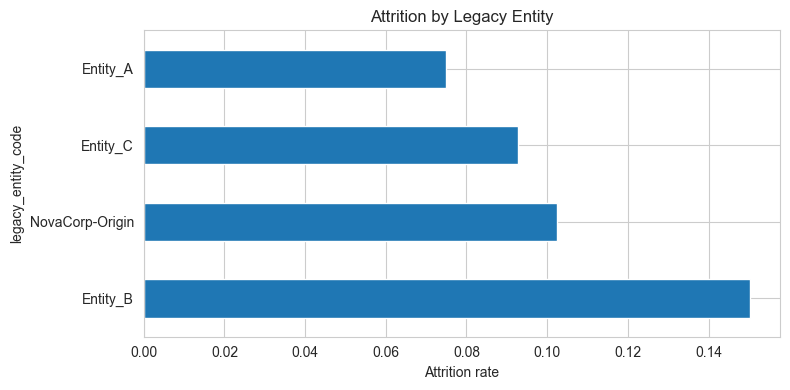

In [23]:
# Visual EDA
plt.figure(figsize=(8, 4))
full.groupby('legacy_entity_code', observed=True)['attrited'].mean().sort_values(ascending=False).plot(kind='barh', color='#1f77b4')
plt.title('Attrition by Legacy Entity')
plt.xlabel('Attrition rate')
plt.tight_layout()
plt.show()


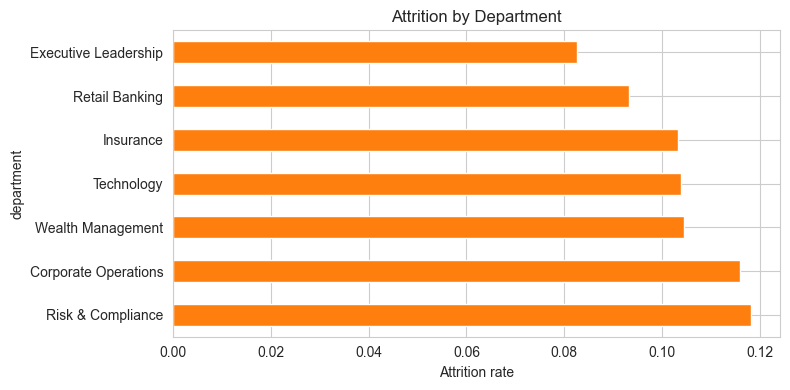

In [24]:
plt.figure(figsize=(8, 4))
full.groupby('department', observed=True)['attrited'].mean().sort_values(ascending=False).plot(kind='barh', color='#ff7f0e')
plt.title('Attrition by Department')
plt.xlabel('Attrition rate')
plt.tight_layout()
plt.show()

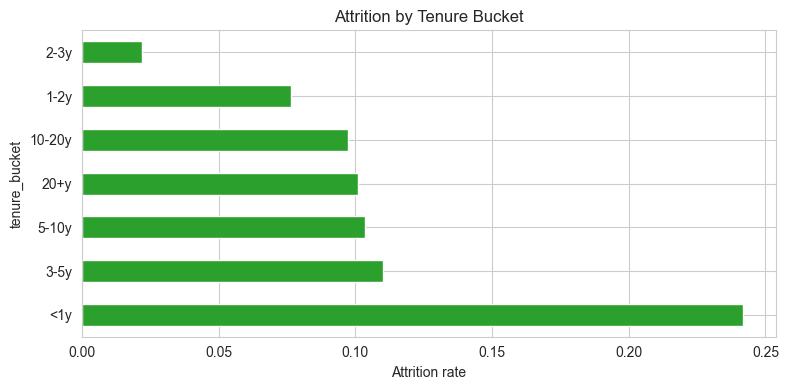

In [25]:
plt.figure(figsize=(8, 4))
full.groupby('tenure_bucket', observed=True)['attrited'].mean().sort_values(ascending=False).plot(kind='barh', color='#2ca02c')
plt.title('Attrition by Tenure Bucket')
plt.xlabel('Attrition rate')
plt.tight_layout()
plt.show()

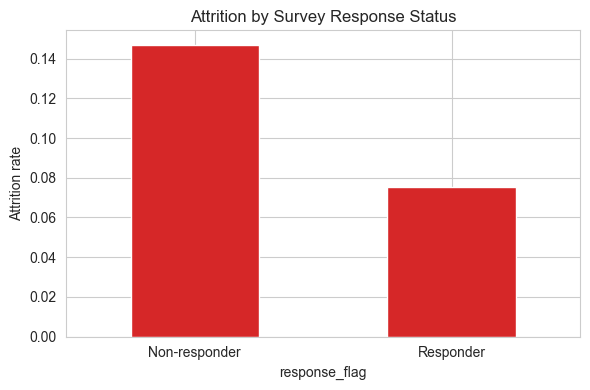

In [26]:
plt.figure(figsize=(6, 4))
full.groupby('response_flag', observed=True)['attrited'].mean().plot(kind='bar', color='#d62728')
plt.title('Attrition by Survey Response Status')
plt.ylabel('Attrition rate')
plt.xticks([0, 1], ['Non-responder', 'Responder'], rotation=0)
plt.tight_layout()
plt.show()
